### Exercise #2 Geomechanics and Structural Geology - 18 February 2026 (Part of Prof. Giovanni Bertotti)

- Pablo Oliver - 6483186
- Nanda Najih Habibil Afif - 6424732
- Lennard Stoeck - 6566545

### *Task 1*
Provide a matrix and a Mohr diagram representation of the following states of stress:

- Hydrostatic compression at a water depth of 3 km
- Uniaxial tension ($\sigma_3$ = -5 MPa)
- Triaxial compression ($\sigma_3$ = 5 MPa; $\sigma_2$ = 8 MPa; $\sigma_1$ = 10 MPa)
- Tension and compression ($\sigma_3$ = -3 MPa; $\sigma_2$ = 0 MPa; $\sigma_1$ = 10 MPa)

### *Solution:*

For this task, the assumptions being used are:

- Compression is positive and tension is negative.
- Principal stress order is $\sigma_1 \geq \sigma_2 \geq \sigma_3$.
- For hydrostatic water load at depth $z = 3$ km:

$$p = \rho_w g z = 1000 \times 9.81 \times 3000 = 29.43\ \text{MPa}$$

- Stress tensor in principal coordinates is:

$$[\sigma] =
\begin{bmatrix}
\sigma_1 & 0 & 0 \\
0 & \sigma_2 & 0 \\
0 & 0 & \sigma_3
\end{bmatrix}$$

- Because each stress state is given with three principal stresses $(\sigma_1, \sigma_2, \sigma_3)$, so it is a 3D state of stress. Mohr circles in 3D are built from the pairs $(\sigma_1, \sigma_2)$, $(\sigma_2, \sigma_3)$, and $(\sigma_1, \sigma_3)$.

Direct formulas used:

- Circle $(\sigma_1, \sigma_2)$:

$$C_{12} = \frac{\sigma_1 + \sigma_2}{2}, \quad R_{12} = \frac{|\sigma_1 - \sigma_2|}{2}$$

- Circle $(\sigma_2, \sigma_3)$:

$$C_{23} = \frac{\sigma_2 + \sigma_3}{2}, \quad R_{23} = \frac{|\sigma_2 - \sigma_3|}{2}$$

- Circle $(\sigma_1, \sigma_3)$:

$$C_{13} = \frac{\sigma_1 + \sigma_3}{2}, \quad R_{13} = \frac{|\sigma_1 - \sigma_3|}{2}$$

$C$ is the center of a Mohr circle, $R$ is the radius of a Mohr circle (equal to the maximum shear stress for that pair).


In [49]:
#Setup

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

def stress_tensor(sig1, sig2, sig3):
    return np.array([
        [sig1, 0.0, 0.0],
        [0.0, sig2, 0.0],
        [0.0, 0.0, sig3],
    ])

def mohr_params(sig1, sig2, sig3):
    pairs = [
        ("(sigma_1, sigma_3)", sig1, sig3),
        ("(sigma_1, sigma_2)", sig1, sig2),
        ("(sigma_2, sigma_3)", sig2, sig3),
    ]
    out = []
    for label, a, b in pairs:
        c = 0.5 * (a + b)
        r = 0.5 * abs(a - b)
        out.append((label, c, r))
    return out

def print_case_results(case_name, s1, s2, s3):
    print(case_name)
    print(f"sigma_1={s1:.2f} MPa, sigma_2={s2:.2f} MPa, sigma_3={s3:.2f} MPa")
    print("Stress matrix [MPa]:")
    print(stress_tensor(s1, s2, s3))
    print("Mohr circles (C, R) [MPa]:")
    for label, c, r in mohr_params(s1, s2, s3):
        print(f"  {label}: C={c:.2f}, R={r:.2f}")

# Case definitions
rho_w = 1000.0
g = 9.81
z = 3000.0
p_hydro = rho_w * g * z / 1e6  # MPa

cases = {
    "Case 1 = Hydrostatic compression (3 km water depth)": (p_hydro, p_hydro, p_hydro),
    "Case 2 = Uniaxial tension": (0.0, 0.0, -5.0),
    "Case 3 = Triaxial compression": (10.0, 8.0, 5.0),
    "Case 4 = Tension and compression": (10.0, 0.0, -3.0),
}

In [50]:
def plot_mohr_3d(ax, s1, s2, s3, title):
    print(f"Plot Mohr: {title}")
    t = np.linspace(0, 2*np.pi, 400)

    circles = [
        ("sigma_1-sigma_3", s1, s3, "tab:red"),
        ("sigma_1-sigma_2", s1, s2, "tab:blue"),
        ("sigma_2-sigma_3", s2, s3, "tab:green"),
    ]

    r_max = 0.0
    for label, a, b, color in circles:
        c = 0.5 * (a + b)
        r = 0.5 * abs(a - b)
        r_max = max(r_max, r)
        sigma = c + r * np.cos(t)
        tau = r * np.sin(t)
        ax.plot(sigma, tau, color=color, lw=2, label=f"{label}: C={c:.2f}, R={r:.2f}")

    # Principal stress points on tau = 0 axis
    ax.scatter([s1, s2, s3], [0, 0, 0], color="black", s=30, zorder=3)

    ax.axhline(0, color="gray", lw=1)
    ax.set_xlabel("Normal stress, sigma_n (MPa)")
    ax.set_ylabel("Shear stress, tau (MPa)")

    # Keep circles circular when R > 0, avoid a flattened strip for hydrostatic case (R = 0)
    if r_max > 1e-12:
        ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_ylim(-0.2, 0.2)

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="upper right")

**Case 1: Hydrostatic compression (3 km water depth)**

Principal stresses:

$$\sigma_1 = \sigma_2 = \sigma_3 = 29.43\ \text{MPa}$$

Stress matrix:

$$[\sigma]_A =
\begin{bmatrix}
29.43 & 0 & 0 \\
0 & 29.43 & 0 \\
0 & 0 & 29.43
\end{bmatrix}\ \text{MPa}$$

Mohr representation: all circles collapse to one point ($R = 0$).

Case 1 = Hydrostatic compression (3 km water depth)
sigma_1=29.43 MPa, sigma_2=29.43 MPa, sigma_3=29.43 MPa
Stress matrix [MPa]:
[[29.43  0.    0.  ]
 [ 0.   29.43  0.  ]
 [ 0.    0.   29.43]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=29.43, R=0.00
  (sigma_1, sigma_2): C=29.43, R=0.00
  (sigma_2, sigma_3): C=29.43, R=0.00
Plot Mohr: Case 1 = Hydrostatic compression (3 km water depth)


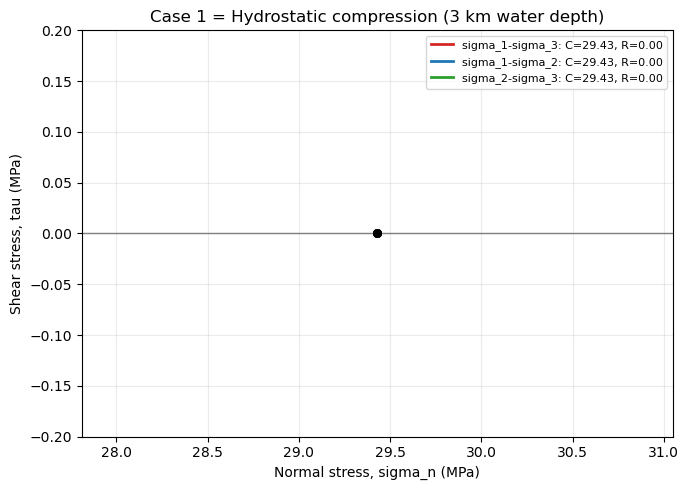

In [51]:
case_name = "Case 1 = Hydrostatic compression (3 km water depth)"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

**Case 2: Uniaxial tension**

Principal stresses:

$$\sigma_1 = 0\ \text{MPa}, \quad \sigma_2 = 0\ \text{MPa}, \quad \sigma_3 = -5\ \text{MPa}$$

Stress matrix:

$$[\sigma]_B =
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -5
\end{bmatrix}\ \text{MPa}$$

Mohr representation: one non-zero circle between $\sigma_1$ and $\sigma_3$ (same as $\sigma_2$ and $\sigma_3$ because $\sigma_1 = \sigma_2$).

Case 2 = Uniaxial tension
sigma_1=0.00 MPa, sigma_2=0.00 MPa, sigma_3=-5.00 MPa
Stress matrix [MPa]:
[[ 0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -5.]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=-2.50, R=2.50
  (sigma_1, sigma_2): C=0.00, R=0.00
  (sigma_2, sigma_3): C=-2.50, R=2.50
Plot Mohr: Case 2 = Uniaxial tension


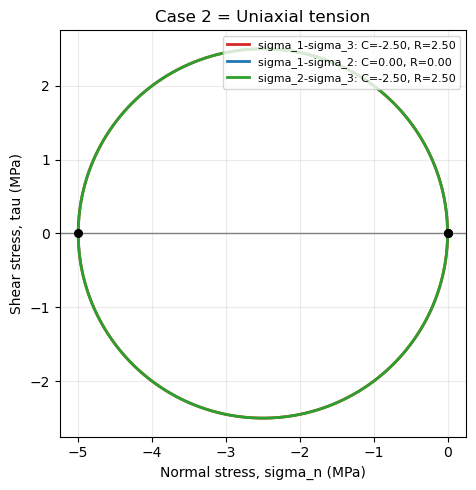

In [52]:
case_name = "Case 2 = Uniaxial tension"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

**Case 3: Triaxial compression**

Principal stresses:

$$\sigma_1 = 10\ \text{MPa}, \quad \sigma_2 = 8\ \text{MPa}, \quad \sigma_3 = 5\ \text{MPa}$$

Stress matrix:

$$[\sigma]_C =
\begin{bmatrix}
10 & 0 & 0 \\
0 & 8 & 0 \\
0 & 0 & 5
\end{bmatrix}\ \text{MPa}$$

Mohr representation: three distinct circles in the compressive stress domain.

Case 3 = Triaxial compression
sigma_1=10.00 MPa, sigma_2=8.00 MPa, sigma_3=5.00 MPa
Stress matrix [MPa]:
[[10.  0.  0.]
 [ 0.  8.  0.]
 [ 0.  0.  5.]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=7.50, R=2.50
  (sigma_1, sigma_2): C=9.00, R=1.00
  (sigma_2, sigma_3): C=6.50, R=1.50
Plot Mohr: Case 3 = Triaxial compression


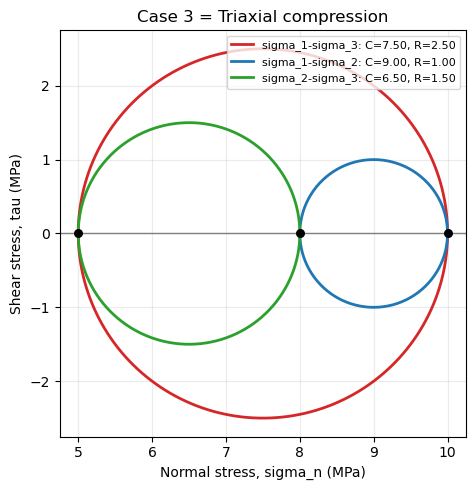

In [53]:
case_name = "Case 3 = Triaxial compression"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

**Case 4: Tension and compression**

Principal stresses:

$$\sigma_1 = 10\ \text{MPa}, \quad \sigma_2 = 0\ \text{MPa}, \quad \sigma_3 = -3\ \text{MPa}$$

Stress matrix:

$$[\sigma]_D =
\begin{bmatrix}
10 & 0 & 0 \\
0 & 0 & 0 \\
0 & 0 & -3
\end{bmatrix}\ \text{MPa}$$

Mohr representation: mixed compression-tension state, with circles spanning negative and positive normal stress.

Case 4 = Tension and compression
sigma_1=10.00 MPa, sigma_2=0.00 MPa, sigma_3=-3.00 MPa
Stress matrix [MPa]:
[[10.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -3.]]
Mohr circles (C, R) [MPa]:
  (sigma_1, sigma_3): C=3.50, R=6.50
  (sigma_1, sigma_2): C=5.00, R=5.00
  (sigma_2, sigma_3): C=-1.50, R=1.50
Plot Mohr: Case 4 = Tension and compression


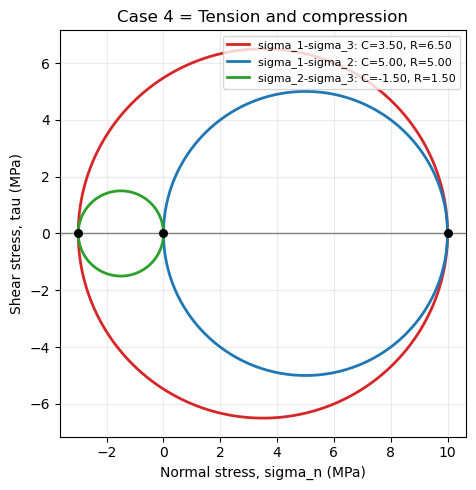

In [54]:
case_name = "Case 4 = Tension and compression"
s1, s2, s3 = cases[case_name]

print_case_results(case_name, s1, s2, s3)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mohr_3d(ax, s1, s2, s3, case_name)
plt.tight_layout()
plt.show()

**Interpretations:**

- Case 1 (hydrostatic compression): all principal stresses are equal, so all three Mohr circles collapse to one point at $\sigma_n = 29.43$ MPa and $\tau = 0$.
- Case 2 (uniaxial tension): one stress is tensile ($\sigma_3 = -5$ MPa), producing circles that cross into negative normal stress domain.
- Case 3 (triaxial compression): all stresses are compressive, producing three distinct circles entirely in positive $\sigma_n$ range.
- Case 4 (tension + compression): mixed stress state gives the largest spread, from negative to positive normal stress, with the largest circle from $\sigma_1$ to $\sigma_3$.
---



### *Task 2*

Using the (2D) Mohr diagram for stress, determine the normal and shear stresses acting on a plane (line in 2D) oriented N30.

Boundary conditions are:
- $\sigma_1$ is oriented N-S and has a magnitude of 13 MPa.
- $\sigma_2$ has a magnitude of 7 MPa.

### *Solution:*

**Given:**
- $\sigma_1 = 13$ MPa (oriented N-S).
- $\sigma_2 = 7$ MPa (perpendicular to $\sigma_1$).
- Plane of interest: oriented N30, so $\theta = 30^\circ$ relative to N-S axis.

Use stress transformation equations:

$$
\sigma_n = \frac{\sigma_1 + \sigma_2}{2} + \frac{\sigma_1 - \sigma_2}{2} \cos(2\theta)
$$

$$
\tau = \frac{\sigma_1 - \sigma_2}{2} \sin(2\theta)
$$

Since $\theta = 30^\circ$, then:

$$
2\theta = 60^\circ
$$

Normal stress:

$$
\sigma_n = \frac{13 + 7}{2} + \frac{13 - 7}{2} \cdot \cos(60^\circ)
$$

$$
\sigma_n = 10 + 1.5 = 11.5\ \text{MPa}
$$

Shear stress:

$$
\tau = \frac{13 - 7}{2} \cdot \sin(60^\circ)
$$

$$
\tau \approx 2.598 \approx 2.6\ \text{MPa}
$$

The Mohr circle is shown as follow:

Normal stress, sigma_n = 11.50 MPa
Shear stress, tau = 2.60 MPa


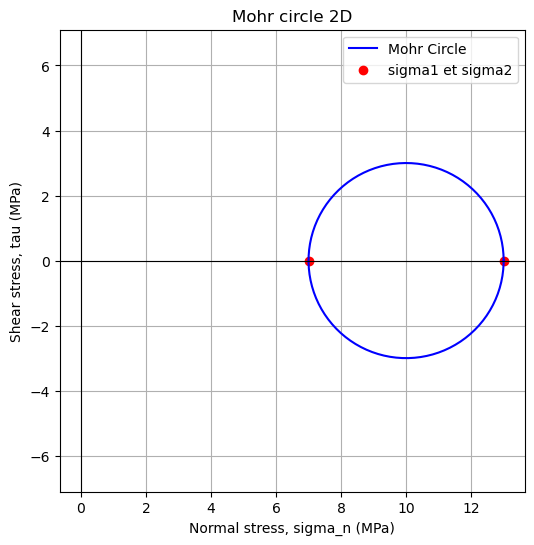

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Data
sigma1 = 13  # MPa
sigma2 = 7   # MPa
theta_deg = 30  

# Radians 
theta = np.deg2rad(theta_deg)

# Stresses on the plane
sigma_n = (sigma1 + sigma2)/2 + (sigma1 - sigma2)/2 * np.cos(2*theta)
tau = (sigma1 - sigma2)/2 * np.sin(2*theta)

print(f"Normal stress, sigma_n = {sigma_n:.2f} MPa")
print(f"Shear stress, tau = {tau:.2f} MPa")

# Mohr circle parameters
C = (sigma1 + sigma2)/2
R = (sigma1 - sigma2)/2

theta_circle = np.linspace(0, 2*np.pi, 200)
x = C + R * np.cos(theta_circle)
y = R * np.sin(theta_circle)

# Plot Mohr circle
plt.figure(figsize=(6,6))
plt.plot(x, y, 'b', label="Mohr Circle")
plt.scatter([sigma1, sigma2], [0, 0], color='red', label='sigma1 et sigma2')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Normal stress, sigma_n (MPa)")
plt.ylabel("Shear stress, tau (MPa)")
plt.title("Mohr circle 2D")
plt.legend(loc="upper right")
plt.grid(True)
plt.axis('equal')
plt.show()

---

### *Task 3*

Stress changes in the KTB borehole (plots on the below):

a) Draw Mohr diagrams to describe the state of stress of rocks at 0.5, 2.5, and 4 km (extrapolate curves when needed).

b) On the same graph, plot a deviatoric stress curve.

c) Using the second plot, determine the position in space of the three principal stresses.

d) Predict the stress regime from surface to a depth of 4 km.

<img src="Task 3 Exercise 1.jpg" alt="Task 3 Exercise 1" width="500">


### *Solution:*

The left plot: showing stress magnitude vs depth for the KTB borehole. The three curves represent the vertical stress $S_V$, maximum horizontal stress $S_H$, and minimum horizontal stress $S_h$ as functions of depth. From the trend lines in the provided KTB plot, we use linear approximations (MPa, depth in km):
$S_V(z) = 28z$; $S_H(z) = 23z + 30$; and $S_h(z) = 11z + 16$.

The right plot: displaying the orientation (azimuth) of the minimum horizontal stress $S_h$ vs depth. This shows that $S_h$ is approximately oriented at N149°E ($\pm 15°$), which helps determine the spatial position of principal stresses in the field.



In [56]:
import numpy as np
import matplotlib.pyplot as plt

# KTB stress trends (stress in MPa, depth magnitude in km)
def sigma_V(depth_km):
    return 28.0 * depth_km

def sigma_H(depth_km):
    return 23.0 * depth_km + 30.0

def sigma_h(depth_km):
    return 11.0 * depth_km + 16.0

def ordered_principal_stresses(z):
    d = abs(z)  # use depth magnitude for stress equations
    vals = np.array([sigma_H(d), sigma_V(d), sigma_h(d)], dtype=float)
    return np.sort(vals)[::-1]  # sigma1, sigma2, sigma3

def mohr_triplet(s1, s2, s3):
    return [
        ("(sigma1,sigma3)", 0.5 * (s1 + s3), 0.5 * (s1 - s3), "tab:red"),
        ("(sigma1,sigma2)", 0.5 * (s1 + s2), 0.5 * (s1 - s2), "tab:blue"),
        ("(sigma2,sigma3)", 0.5 * (s2 + s3), 0.5 * (s2 - s3), "tab:green"),
    ]

def plot_mohr_at_depth(z):
    s1, s2, s3 = ordered_principal_stresses(z)
    circles = mohr_triplet(s1, s2, s3)
    theta = np.linspace(0, 2 * np.pi, 400)

    fig, ax = plt.subplots(figsize=(6, 5))
    for label, c, r, color in circles:
        x = c + r * np.cos(theta)
        y = r * np.sin(theta)
        ax.plot(x, y, color=color, lw=2, label=f"{label}: C={c:.1f}, R={r:.1f}")

    ax.scatter([s1, s2, s3], [0, 0, 0], color="black", s=25, zorder=3)
    ax.axhline(0, color="gray", lw=1)
    ax.set_title(f"Mohr diagram at z={z:.1f} km")
    ax.set_xlabel("Normal stress, sigma_n (MPa)")
    ax.set_ylabel("Shear stress, tau (MPa)")
    ax.grid(alpha=0.25)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

def plot_deviatoric_curve(depths_eval):
    z_curve = np.linspace(0, -4, 200)
    q_curve = []
    for z in z_curve:
        s1, _, s3 = ordered_principal_stresses(z)
        q_curve.append(s1 - s3)
    q_curve = np.array(q_curve)

    q_eval = []
    for z in depths_eval:
        s1, _, s3 = ordered_principal_stresses(z)
        q_eval.append(s1 - s3)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(q_curve, z_curve, color="tab:red", lw=2.5, label="q(deviatoric stress) = sigma1 - sigma3")
    ax.scatter(q_eval, depths_eval, color="black", s=25, zorder=3, label="evaluated depths")
    
    # Annotate each point with (q, depth)
    for q, z in zip(q_eval, depths_eval):
        ax.annotate(f'({q:.1f}, {z:.1f})', 
                   xy=(q, z), 
                   xytext=(5, 5), 
                   textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    
    ax.set_xlabel("Deviatoric stress q (MPa)")
    ax.set_ylabel("Depth (km)")
    ax.set_title("Deviatoric stress curve")
    ax.set_xlim(0, 120)
    ax.set_ylim(-4, 0)
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

depths_eval = [-0.5, -2.5, -4.0]

#### **(a) Mohr Diagrams of rocks at 0.5, 2.5 and 4 kms**

**Mohr diagram at z = -0.5 km**

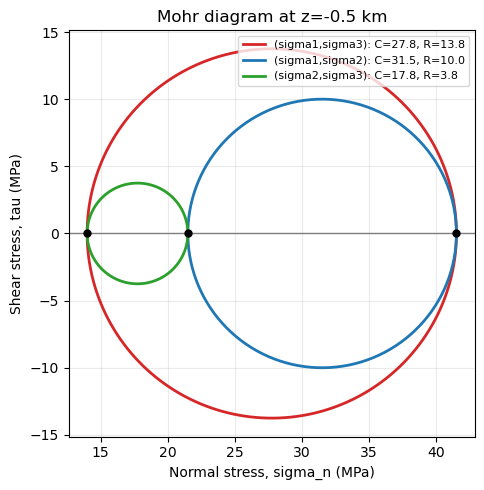

In [57]:
plot_mohr_at_depth(-0.5)

At depth 0.5 km, we can get information:
- $\sigma_H = 23(0.5) + 30 = 41.5$ MPa
- $\sigma_V = 28(0.5) = 14.0$ MPa
- $\sigma_h = 11(0.5) + 16 = 21.5$ MPa

Order of stresses at this depth: $\sigma_H > \sigma_h > \sigma_V$, so $\sigma_1 = 41.5$ MPa, $\sigma_2 = 21.5$ MPa, $\sigma_3 = 14.0$ MPa

So, *deviatoric stress:* $q = \sigma_1 - \sigma_3 = 41.5 - 14.0 = 27.5$ MPa.

**Mohr diagram at z = -2.5 km**

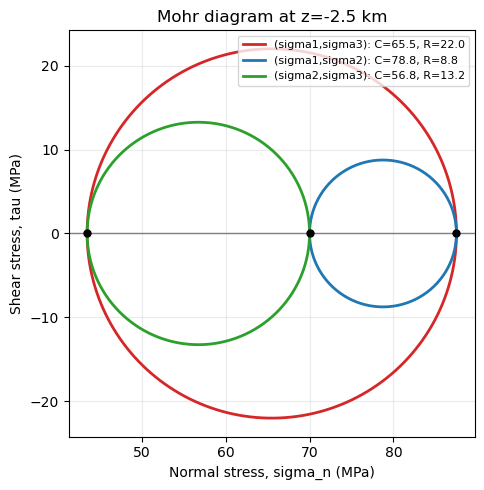

In [58]:
plot_mohr_at_depth(-2.5)

At depth 2.5 km, we found that:
- $\sigma_H = 23(2.5) + 30 = 87.5$ MPa
- $\sigma_V = 28(2.5) = 70.0$ MPa
- $\sigma_h = 11(2.5) + 16 = 43.5$ MPa

Order of stresses at this depth: $\sigma_H > \sigma_V > \sigma_h$, so $\sigma_1 = 87.5$ MPa, $\sigma_2 = 70.0$ MPa, $\sigma_3 = 43.5$ MPa

So, the *deviatoric stress*: $q = \sigma_1 - \sigma_3 = 87.5 - 43.5 = 44.0$ MPa (positive, larger than at 0.5 km)

**Mohr diagram at z = -4.0 km**

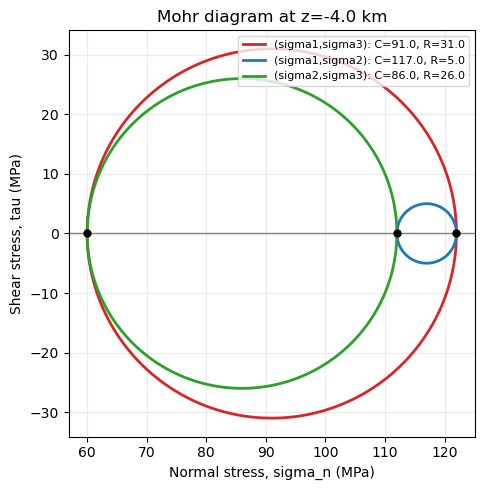

In [59]:
plot_mohr_at_depth(-4.0)

At depth 4.0 km, we found:
- $\sigma_H = 23(4.0) + 30 = 122.0$ MPa
- $\sigma_V = 28(4.0) = 112.0$ MPa
- $\sigma_h = 11(4.0) + 16 = 60.0$ MPa

Order of stresses at this depth: $\sigma_H > \sigma_V > \sigma_h$, so $\sigma_1 = 122.0$ MPa, $\sigma_2 = 112.0$ MPa, $\sigma_3 = 60.0$ MPa

Therefore, *deviatoric stress*: $q = \sigma_1 - \sigma_3 = 122.0 - 60.0 = 62.0$ MPa (positive, largest among the three depths)

#### **(b) Deviatoric Stress Curve (0-4 km)**

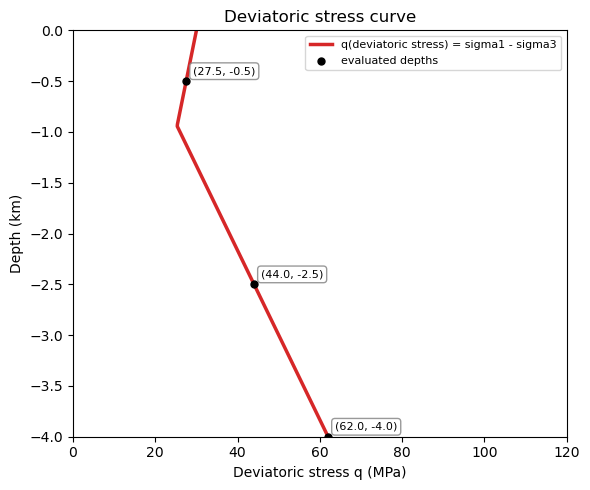

In [60]:
plot_deviatoric_curve(depths_eval)

Completing the deviatoric plot in the above graph, another version of a plot with overlay of KTB borohole stress vs depth is :

<img src="Answer of Task 3 Exercise 1 (deviatoric).jpg" alt="Deviatoric stress overlay" width="400">



#### **(c) Determining The Position in Space of The Three Principal Stresses (Using Graph b)**

From the figure provided (plot b) in the task, $S_h$ is horizontal with average azimuth N149°E ($\pm 15°$). $S_H$ is horizontal and perpendicular to $S_h$ (approximately N59°E or N239°E). $S_V$ is vertical.




#### **(d) Predicting The Stress Regime from The Surface to A Depth of 4 km**

To determine stress regime, we need to identify the crossover depth (that we can see it in graph *a* in the task) where $S_V = S_h$:

$$28z = 11z + 16$$
$$z = 0.94 \text{ km}$$

This creates two stress regimes:

**Regime 1: Shallower interval (0 - 0.94 km)**
- Stress ordering: $S_H > S_h > S_V$
- Principal stresses: $\sigma_1 = S_H$ (horizontal), $\sigma_2 = S_h$ (horizontal), $\sigma_3 = S_V$ (vertical)
- Since horizontal stress is the largest while vertical stress is the smallest, this zone is strike-slip faulting regime.

**Regime 2: Deeper interval (0.94 - 4 km)**
- Stress ordering: $S_H > S_V > S_h$
- Principal stresses: $\sigma_1 = S_H$ (horizontal), $\sigma_2 = S_V$ (vertical), $\sigma_3 = S_h$ (horizontal)
- Since horizontal stress is the largest while vertical stress is in between, this zone is strike-slip faulting regime with an obqlique possible movement.

---

### *Task 4*

**Spanish Peak stress field(s)**

The Spanish peak volcanic system is composed of an intrusive "plug" and a large number of dykes. As you see from the map, the pattern of these dykes is not random.

1) What are the relations between dykes and principal stresses?

2) What is the minimum number of stress fields which you can define? Explain your answer.

3) Draw the stress trajectories associated with the stress fields you have defined (use the map on the following page).

4) Define the tectonic origin of the stress field(s).

5) Make a geologic history of the area.

<img src="Task 4 Exercise 1.jpg" alt="Task 4 Exercise 1" width="400">


### *Solution:*

1. Dykes will grow parallel to the $\sigma_1$ direction. As, the magmatic plug (the red colour part in the map) has such strong confinement that was strong enough to retain any upcoming pressure from the bottom. Therefore, the dykes intrusion was transmitted to fractures which likely occured parallel to $\sigma_1$, which also acted as maximum horizontal stress.